Import de dataset y librerias

In [231]:
import pandas as pd
import numpy as np
from skforecast.recursive import ForecasterRecursive
import shap
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skforecast.model_selection import grid_search_forecaster
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

dataset = 'CTC_processed.csv'
                              
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data = data.sort_index() #Ordenar por fecha

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed', 'rain', 'pressure', 'month', 'day', 'hour', 'minute']


Dividimos en train y test

In [232]:
train_size = int(len(data) * 0.8)

data_train = data.iloc[:train_size]   
data_test  = data.iloc[train_size:]   

Escalamos los datos.

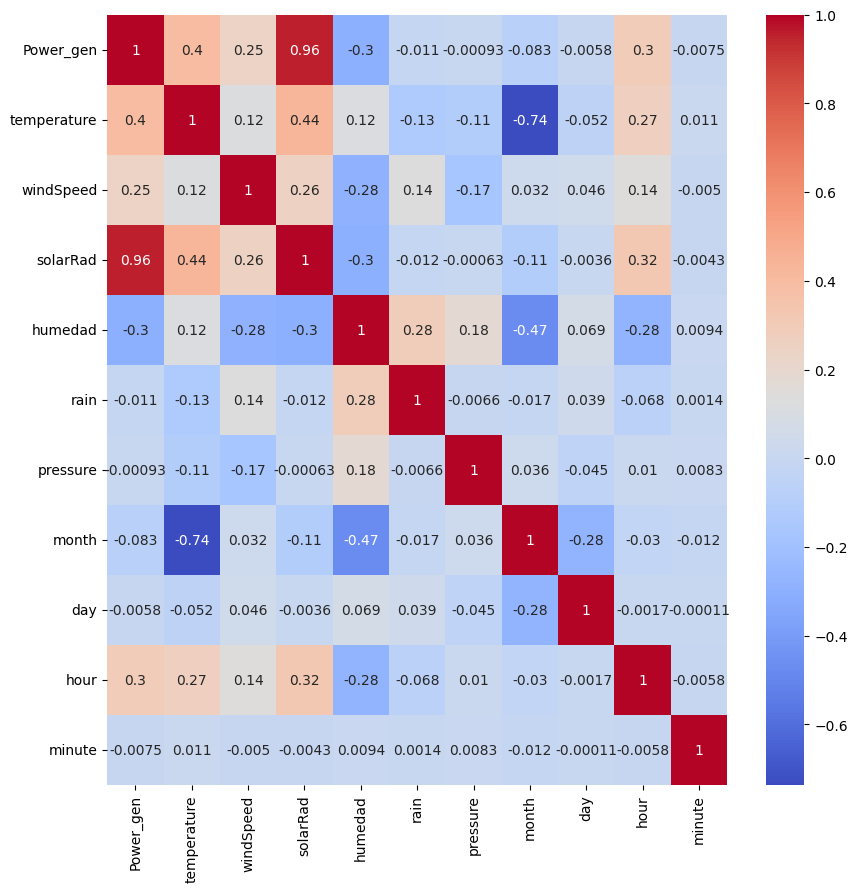

In [233]:
scaler = MinMaxScaler()
#entrenamiento
train_scaled = data_train.copy()
train_scaled[exogenas] = scaler.fit_transform(data_train[exogenas])

corr_df = train_scaled.corr(method ='spearman')

#test
test_scaled = data_test.copy()
test_scaled[exogenas] = scaler.fit_transform(data_test[exogenas])

corr_df = test_scaled.corr(method ='spearman')

plt.figure(figsize=(10, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')

plt.show()

Obtenemos los parámetros óptimos del modelo

In [234]:
'''from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import random_search_forecaster
from xgboost import XGBRegressor
from skforecast.model_selection import TimeSeriesFold

param_distributions = {
    'learning_rate': [0.01, 0.6],
    'max_depth': [3, 9],
    'n_estimators': [200, 900],
    'subsample': [0.6, 1.0]
}

forecaster = ForecasterRecursive(
    estimator = XGBRegressor(
        n_jobs=-1,
        tree_method="hist"   # mucho más rápido
    ),
    lags = 7
)

cv = TimeSeriesFold(
    initial_train_size = int(len(data_train) * 0.2),  # más grande para menos folds
    steps = 366,
    gap = 0
)

search_result = random_search_forecaster(
    forecaster      = forecaster,
    y               = data_train['Power_gen'],
    exog            = data_train[exogenas],
    param_distributions = param_distributions,
    n_iter          = 10,          # solo 10 combinaciones
    cv              = cv,
    metric          = 'mean_absolute_error',
    return_best     = True,
    verbose         = True
)'''


'from skforecast.recursive import ForecasterRecursive\nfrom skforecast.model_selection import random_search_forecaster\nfrom xgboost import XGBRegressor\nfrom skforecast.model_selection import TimeSeriesFold\n\nparam_distributions = {\n    \'learning_rate\': [0.01, 0.6],\n    \'max_depth\': [3, 9],\n    \'n_estimators\': [200, 900],\n    \'subsample\': [0.6, 1.0]\n}\n\nforecaster = ForecasterRecursive(\n    estimator = XGBRegressor(\n        n_jobs=-1,\n        tree_method="hist"   # mucho más rápido\n    ),\n    lags = 7\n)\n\ncv = TimeSeriesFold(\n    initial_train_size = int(len(data_train) * 0.2),  # más grande para menos folds\n    steps = 366,\n    gap = 0\n)\n\nsearch_result = random_search_forecaster(\n    forecaster      = forecaster,\n    y               = data_train[\'Power_gen\'],\n    exog            = data_train[exogenas],\n    param_distributions = param_distributions,\n    n_iter          = 10,          # solo 10 combinaciones\n    cv              = cv,\n    metric     

Evolucion de las variables exogenas

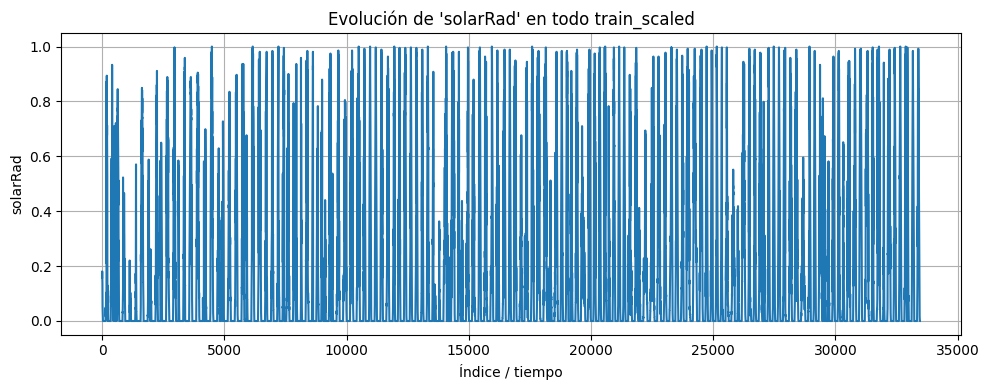

In [235]:
var = "solarRad"  #variable a analizar

plt.figure(figsize=(10, 4))
plt.plot(train_scaled.index, train_scaled[var])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en todo train_scaled")
plt.grid(True)
plt.tight_layout()
plt.show()


Valores de las exogenas para un dia en concreto

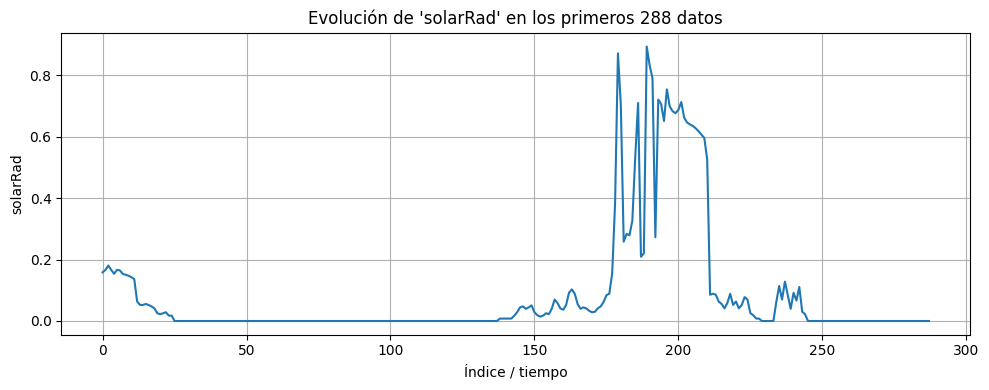

In [236]:
pasos_dia = (24 * 60 // 5)   #288 primer dia de data_train (datos cada 5 minutos)

plt.figure(figsize=(10, 4))
plt.plot(train_scaled.index[:pasos_dia], train_scaled[var].iloc[:pasos_dia])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en los primeros {pasos_dia} datos")
plt.grid(True)
plt.tight_layout()
plt.show()


El primer paso es crear el forecaster.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
forecaster = ForecasterRecursive(
    estimator = DecisionTreeRegressor(max_depth = 6, random_state = 42, min_samples_leaf=50),
    lags = 7
)

Entrenamos el modelo.

In [238]:
X_test, y_test = forecaster.create_train_X_y(y=test_scaled['Power_gen'], exog=test_scaled[exogenas])
X_train, y_train = forecaster.create_train_X_y(y=train_scaled['Power_gen'], exog=train_scaled[exogenas])

forecaster.fit(y=train_scaled['Power_gen'], exog=train_scaled[exogenas])

Comprobamos si hay overfitting y entrenamos. El early_stop = 50, por lo que el modelo se detendrá cuando no haya mejorado en 50 iteraciones el valor de validación. La reducción del error segun avanza el train indica la efectiva eliminacion de perdidas. Alcanza una estabilización al final, lo que significa el final del proceso de entrenamiento. El comportamiento del modelo en entrenamiento y validacion es consistente, lo que confirma la no presencia de sobreentrenamiento en los datos.

In [239]:
'''model = forecaster.estimator

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose = False)

results = model.evals_result()

#print(f"Mejor iteracion: {forecaster.estimator.best_iteration}")
plt.figure(figsize=(10,6))
plt.plot(results['validation_0']['rmse'], label='Error entrenamiento')
plt.plot(results['validation_1']['rmse'], label='Error validacion')
plt.xlabel('Numero de arboles (Iteraciones)')
plt.ylabel('RMSE')
plt.title('Deteccion de overfitting')
plt.legend()
plt.show()'''

'model = forecaster.estimator\n\nmodel.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose = False)\n\nresults = model.evals_result()\n\n#print(f"Mejor iteracion: {forecaster.estimator.best_iteration}")\nplt.figure(figsize=(10,6))\nplt.plot(results[\'validation_0\'][\'rmse\'], label=\'Error entrenamiento\')\nplt.plot(results[\'validation_1\'][\'rmse\'], label=\'Error validacion\')\nplt.xlabel(\'Numero de arboles (Iteraciones)\')\nplt.ylabel(\'RMSE\')\nplt.title(\'Deteccion de overfitting\')\nplt.legend()\nplt.show()'

Obtenemos las variables mas importantes en el forecaster

In [240]:
importancia = forecaster.get_feature_importances()
print(importancia)

        feature  importance
0         lag_1    0.908103
8      solarRad    0.081056
15         hour    0.007370
1         lag_2    0.002889
5         lag_6    0.000511
6         lag_7    0.000047
13        month    0.000025
4         lag_5    0.000000
3         lag_4    0.000000
7   temperature    0.000000
2         lag_3    0.000000
9       humedad    0.000000
10    windSpeed    0.000000
12     pressure    0.000000
11         rain    0.000000
14          day    0.000000
16       minute    0.000000


Usamos SHAP para crear los datos de entrenamiento

In [241]:
x_train, y_train = forecaster.create_train_X_y(
    y=train_scaled['Power_gen'],
    exog=train_scaled[exogenas]
)

print(x_train.head()) 
print(y_train.head()) 

    lag_1  lag_2  lag_3  lag_4  lag_5  lag_6  lag_7  temperature  solarRad  \
7    68.0   70.0   69.0   78.0   82.0   70.0   65.0     0.522171  0.153724   
8    60.0   68.0   70.0   69.0   78.0   82.0   70.0     0.518349  0.150555   
9    61.0   60.0   68.0   70.0   69.0   78.0   82.0     0.518349  0.147385   
10   62.0   61.0   60.0   68.0   70.0   69.0   78.0     0.518349  0.142631   
11   57.0   62.0   61.0   60.0   68.0   70.0   69.0     0.525994  0.136292   

    humedad  windSpeed  rain  pressure  month       day      hour    minute  
7      0.12   0.645985   0.0  0.272727    0.0  0.766667  0.608696  0.169492  
8      0.12   0.704380   0.0  0.272727    0.0  0.766667  0.608696  0.254237  
9      0.12   0.762774   0.0  0.272727    0.0  0.766667  0.608696  0.338983  
10     0.10   0.762774   0.0  0.272727    0.0  0.766667  0.608696  0.423729  
11     0.06   0.529197   0.0  0.272727    0.0  0.766667  0.608696  0.508475  
7     60
8     61
9     62
10    57
11    54
Name: y, dtype: in

Explainer del SHAP

In [242]:
explainer = shap.Explainer(forecaster.estimator)

#50% de los datos de entrenamiento
rng = np.random.default_rng(42)
sample_indices = rng.choice(x_train.index, size=int(len(x_train) * 0.5), replace=False)
x_train_sample = x_train.loc[sample_indices,:]
shap_values = explainer.shap_values(x_train_sample)

Grafica resumen de SHAP

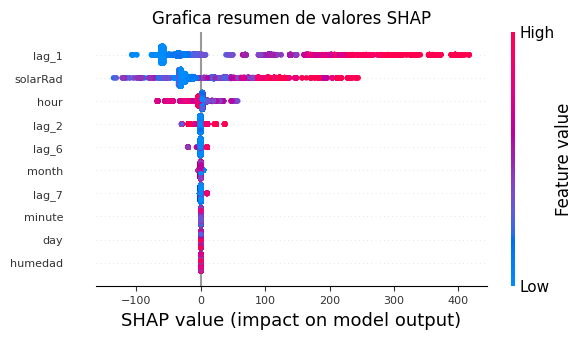

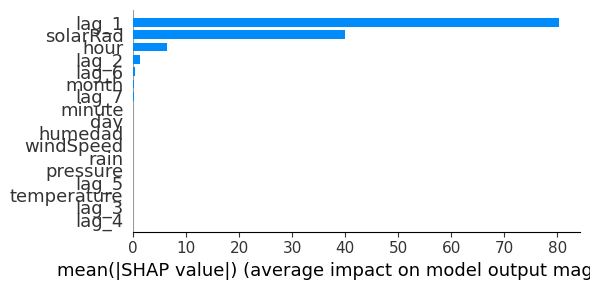

In [243]:
shap.initjs()
shap.summary_plot(shap_values, x_train_sample, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.set_title('Grafica resumen de valores SHAP')
ax.tick_params(labelsize=8)
fig.set_size_inches(6,3)
plt.show()


plt.figure()
shap.summary_plot(shap_values, x_train, plot_type="bar", plot_size=(6, 3))
plt.show()

Grafica de dependencia

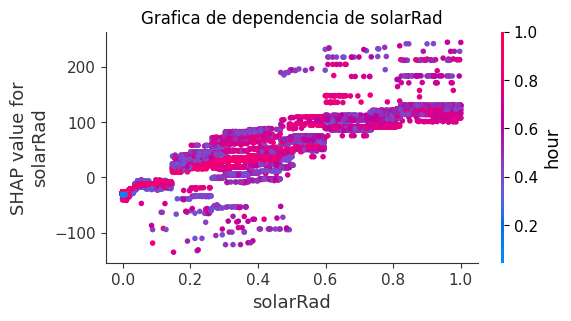

In [244]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Grafica de dependencia de solarRad')

shap.dependence_plot("solarRad", shap_values, x_train_sample, ax=ax)
plt.show()

Primero, veremos las explicaciones de SHAP para predicciones de las proximas 8364 muestras (data_test)

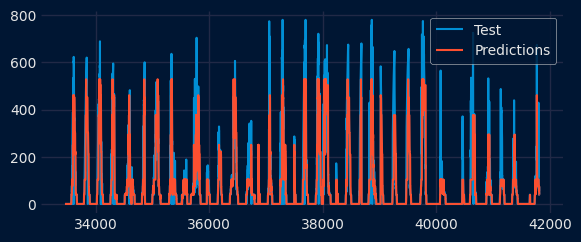

In [245]:
pred = forecaster.predict(steps=len(test_scaled), exog=test_scaled[exogenas])

set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 2.5))
test_scaled['Power_gen'].plot(ax=ax, label='Test')
pred.plot(ax=ax, label='Predictions', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()

Ahora veremos la explicacion de SHAP para la predicción de un día en concreto.

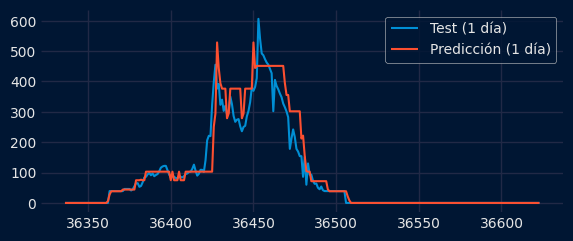

In [246]:
pasos_dia = 24 * 60 // 5   #288

#Ahora recorta solo un día para graficar
idx_ini = 10 * pasos_dia #dia en concreto
y_real_dia = test_scaled['Power_gen'].iloc[idx_ini:idx_ini + pasos_dia]
pred_dia   = pred.iloc[idx_ini:idx_ini + pasos_dia]

fig, ax = plt.subplots(figsize=(6, 2.5))
y_real_dia.plot(ax=ax, label='Test (1 día)')
pred_dia.plot(ax=ax, label='Predicción (1 día)', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()


Para dos dias.

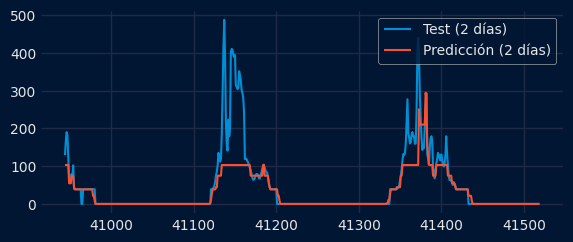

In [247]:
pasos_dia = 2 * (24 * 60 // 5)   #288

#Ahora recorta solo un día para graficar
idx_ini = 13 * pasos_dia #dia en concreto
y_real_dia = test_scaled['Power_gen'].iloc[idx_ini:idx_ini + pasos_dia]
pred_dia   = pred.iloc[idx_ini:idx_ini + pasos_dia]

fig, ax = plt.subplots(figsize=(6, 2.5))
y_real_dia.plot(ax=ax, label='Test (2 días)')
pred_dia.plot(ax=ax, label='Predicción (2 días)', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()


Graficas de dependencia parcial.

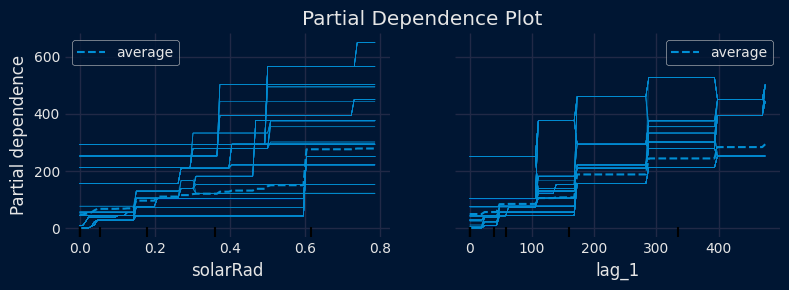

In [248]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = x_train,
    features  = ["solarRad", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

Metricas de la prediccion

In [249]:
y_test = test_scaled['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 26.1985
Mean Squared Error (MSE): 4612.5816
Root Mean Squared Error (RMSE): 67.9160
Coeficiente de determinación (R^2): 0.7739


Añadimos una variable extra, la irrandiancia ideal, de forma que ayude al modelo a saber hasta que valor podría llegar a ascender.

In [250]:
t_min = data["hour"] * 60 + data["minute"]
t_day = 24 * 60

t_mid = 13 * 60   
x = (t_min - t_mid) / (t_day / 2)   

irr_ideal_norm = np.clip(1 - x**2, 0, 1) 

IRR_MAX = 631 #maxima solarRad en el dataset 
train_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm
test_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm

In [251]:
exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed',
            'rain', 'pressure', 'month', 'day', 'hour', 'minute',
            'irr_ideal']


forecaster.fit(y=train_scaled["Power_gen"],
               exog=train_scaled[exogenas])

pred = forecaster.predict(steps=len(test_scaled),
                          exog=test_scaled[exogenas])


Nuevas métricas de la predicción, ligeramente mejores.

In [252]:
y_test = data_test['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 21.0821
Mean Squared Error (MSE): 2921.2526
Root Mean Squared Error (RMSE): 54.0486
Coeficiente de determinación (R^2): 0.8568


Comparativa realidad vs prediccion

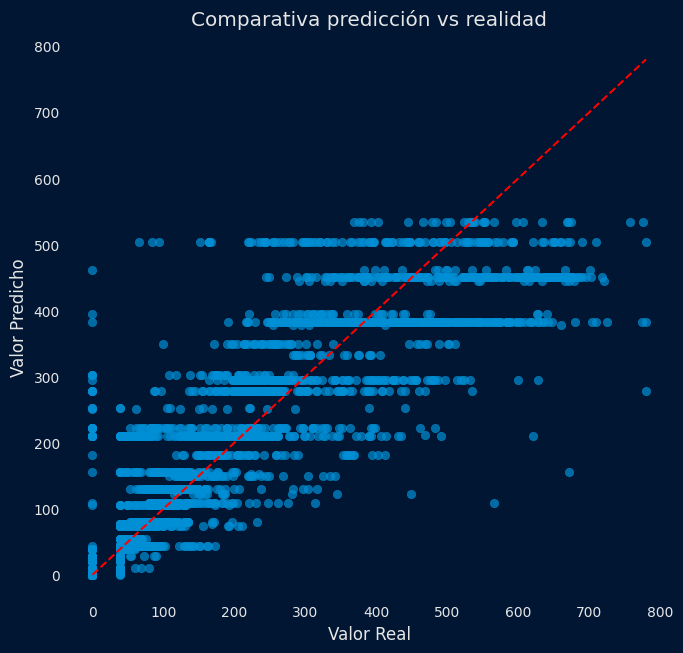

In [253]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()

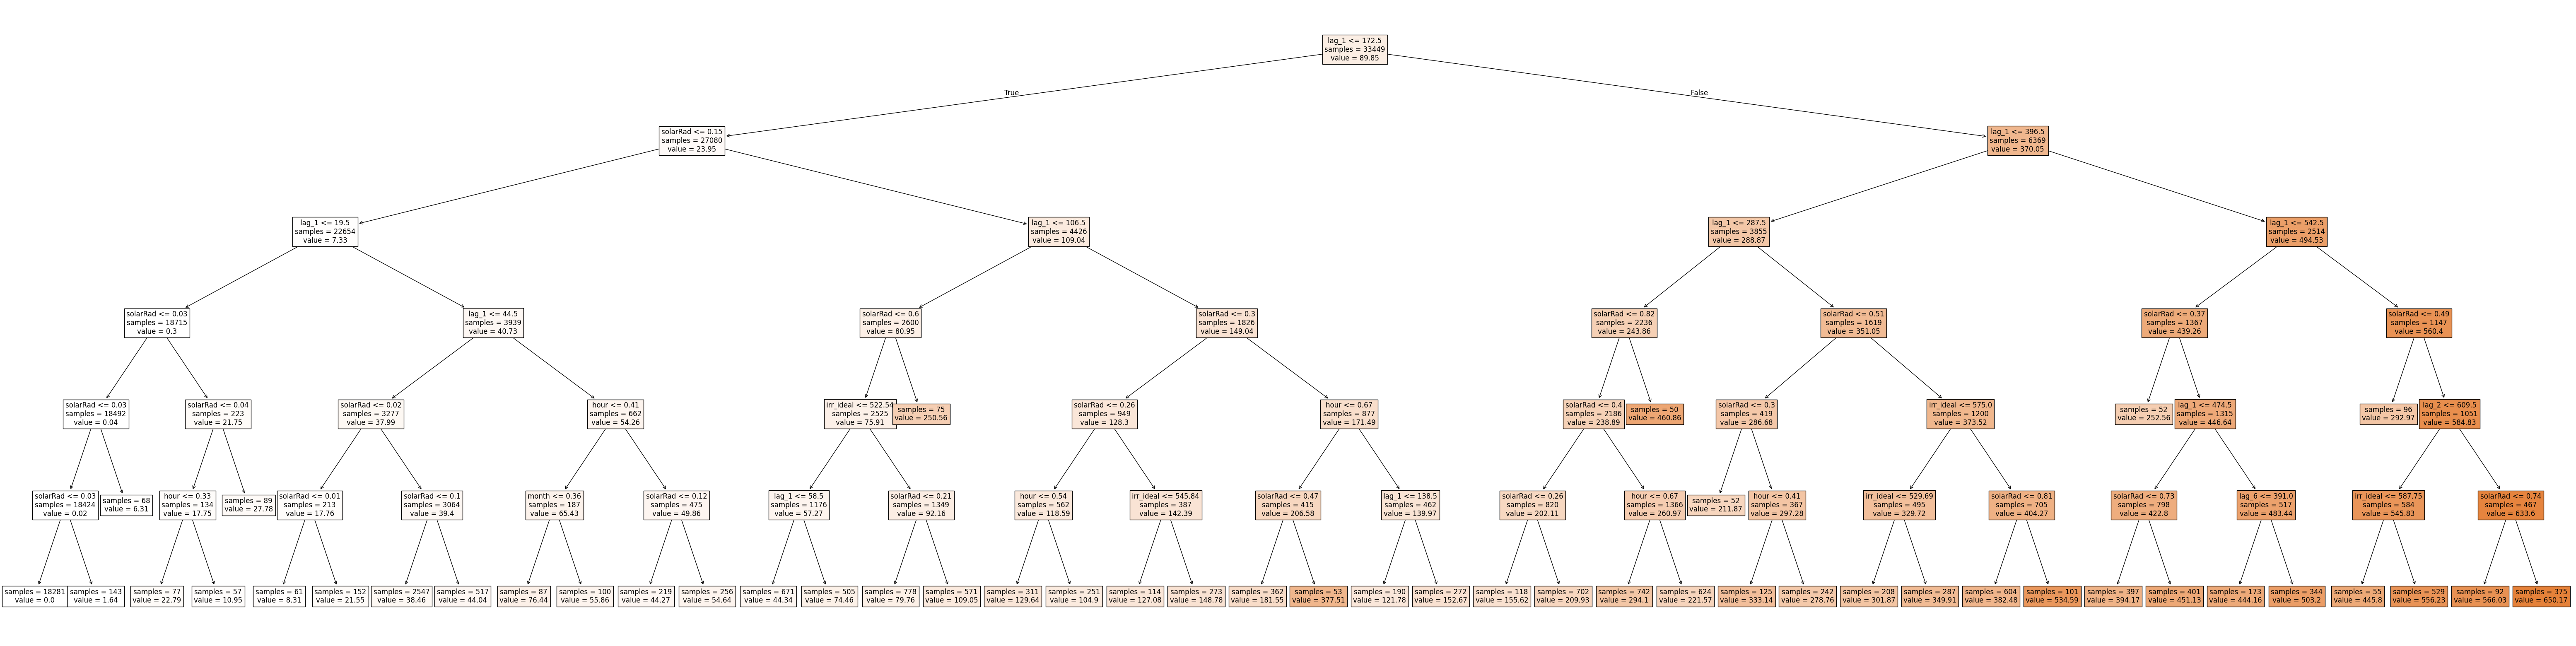

In [270]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.style.use('default') 

modelo_arbol = forecaster.estimator

fig = plt.figure(figsize=(80, 20), facecolor='white')
ax = fig.add_subplot(111)

plot_tree(
    modelo_arbol, 
    feature_names = forecaster.X_train_features_names_out_,
    filled = True,
    max_depth = 7,
    fontsize = 12,
    precision = 2,
    ax = ax,
    impurity = False, 
    proportion = False
)

for text in ax.texts:
    text.set_color('black')

plt.show()